In [24]:
#import sys
#sys.executable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [3]:
df = pd.read_csv("listings.csv")
df.shape

(16392, 27)

In [4]:
df.head()

,id,url,title,price,currency,location,description_en,description_native,construction_of_building,condition,equipped,area_of_property,usable_area,floor,disposition,ownership,city_location,age,garage,elevator,balcony,parking,barrier_free_access,cellar,near_public_transport,terrace,created_at
0,1,https://www.bezrealitky.cz/nemovitosti-byty-do...,Inzerát již není v nabídce Pronájem bytu 1+1 •...,8000.0,CZK,"sídliště 9. května, Nejdek - Nejdek, Karlovars...",NaN,Rádi bychom Vám představili tento byt k pronáj...,Cihla,Dobrý,Částečně,NaN,37,1. podlaží z 3,1+1,NaN,Klidná část,NaN,f,f,f,f,f,t,f,f,2026-02-25 16:25:31.95146
1,2,https://www.bezrealitky.cz/nemovitosti-byty-do...,Inzerát již není v nabídce Pronájem kanceláře ...,0.0,EUR,", Severní Porýní-Vestfálsko",NaN,V této krásné kancelářské budově se středovou ...,NaN,Velmi dobrý,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nad 50 let,f,t,f,t,t,f,t,f,2026-02-25 16:25:32.462684
2,3,https://www.bezrealitky.cz/nemovitosti-byty-do...,Inzerát již není v nabídce Prodej bytu 6+1 • 2...,534000.0,EUR,Bozener Str 64 Ludwigshafen Gartenstadt Rheinl...,NaN,"Na prodej je balík, který zahrnuje prostorný b...",NaN,NaN,NaN,NaN,235,1. podlaží z 2,6+1,NaN,NaN,Nad 50 let,t,t,t,f,t,t,t,f,2026-02-25 16:25:32.972321
3,4,https://www.bezrealitky.cz/nemovitosti-byty-do...,Inzerát již není v nabídce Prodej domu 7+1 • 2...,749000.0,EUR,", Severní Porýní-Vestfálsko",NaN,Níže naleznete překlad textu označeného XML ta...,NaN,Po rekonstrukci,NaN,850,278,NaN,7+1,NaN,NaN,Nad 50 let,t,f,t,t,f,t,t,t,2026-02-25 16:25:33.493882
4,5,https://www.bezrealitky.cz/nemovitosti-byty-do...,Inzerát již není v nabídce Prodej bytu 2+1 • 3...,165000.0,EUR,Mendelsohnstraße 12 Augsburg Oberhausen Bayern...,NaN,Atraktivní 2-pokojový investiční byt a byt pro...,NaN,Před rekonstrukcí,NaN,NaN,38,NaN,2+1,NaN,NaN,Nad 50 let,f,f,f,f,f,t,t,f,2026-02-25 16:25:33.896546


# Structural overview

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16392 entries, 0 to 16391
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        16392 non-null  int64  
 1   url                       16392 non-null  str    
 2   title                     16392 non-null  str    
 3   price                     9488 non-null   float64
 4   currency                  9488 non-null   str    
 5   location                  16391 non-null  str    
 6   description_en            1175 non-null   str    
 7   description_native        16304 non-null  str    
 8   construction_of_building  3625 non-null   str    
 9   condition                 7391 non-null   str    
 10  equipped                  3643 non-null   str    
 11  area_of_property          2910 non-null   str    
 12  usable_area               7348 non-null   str    
 13  floor                     5093 non-null   str    
 14  disposition      

## Data pre-processing
- drop id column
- convert booleans into 0 or 1
- convert area columns into floats

In [6]:
df.drop("id", axis=1, inplace=True)

# List of boolean columns
bool_cols = ["garage", "elevator", "balcony", "parking", 
             "barrier_free_access", "cellar", "near_public_transport", "terrace"]

# Replace 't' -> 1, 'f' -> 0
df[bool_cols] = df[bool_cols].replace({"t": 1, "f": 0}).astype(int)

df["usable_area"] = pd.to_numeric(df["usable_area"], errors="coerce") # convert string to numeric value
df["area_of_property"] = pd.to_numeric(df["area_of_property"], errors="coerce") 

### Let 's check it

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16392 entries, 0 to 16391
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   url                       16392 non-null  str    
 1   title                     16392 non-null  str    
 2   price                     9488 non-null   float64
 3   currency                  9488 non-null   str    
 4   location                  16391 non-null  str    
 5   description_en            1175 non-null   str    
 6   description_native        16304 non-null  str    
 7   construction_of_building  3625 non-null   str    
 8   condition                 7391 non-null   str    
 9   equipped                  3643 non-null   str    
 10  area_of_property          1531 non-null   float64
 11  usable_area               7322 non-null   float64
 12  floor                     5093 non-null   str    
 13  disposition               6664 non-null   str    
 14  ownership        

In [8]:
df.describe(include="all")

,url,title,price,currency,location,description_en,description_native,construction_of_building,condition,equipped,area_of_property,usable_area,floor,disposition,ownership,city_location,age,garage,elevator,balcony,parking,barrier_free_access,cellar,near_public_transport,terrace,created_at
count,16392,16392,9.488000e+03,9488,16391,1175,16304,3625,7391,3643,1531.000000,7322.000000,5093,6664,2641,2932,4240,16392.000000,16392.000000,16392.000000,16392.000000,16392.000000,16392.000000,16392.000000,16392.000000,16392
unique,16392,14456,NaN,2,9632,1171,16267,7,11,3,NaN,NaN,146,22,4,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16392
top,https://www.bezrealitky.cz/nemovitosti-byty-do...,"Pronájem chaty, chalupy • 4 ložnice bez realit...",NaN,CZK,", Bádensko-Württembersko",I am offering a studio apartment (1+kk) for re...,Nabízíme k pronájmu kancelářské a nebytové pro...,Cihla,Velmi dobrý,Částečně,NaN,NaN,Přízemí,2+1,Osobní,Klidná část,Nad 50 let,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-25 16:25:31.95146
freq,1,12,NaN,4890,308,2,2,2343,2282,1444,NaN,NaN,405,1260,2474,2011,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,1.497133e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498.697583,92.469817,NaN,NaN,NaN,NaN,NaN,0.124573,0.146047,0.165508,0.206747,0.065703,0.240117,0.450037,0.115361,NaN
std,NaN,NaN,5.941135e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.060617,83.928417,NaN,NaN,NaN,NaN,NaN,0.330244,0.353164,0.371649,0.404985,0.247769,0.427167,0.497513,0.319467,NaN
min,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,2.750000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.500000,50.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,3.339900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,482.000000,70.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,5.552500e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,702.500000,105.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN


In [9]:
df.isna().mean().sort_values(ascending=False) # percentage of missing values per column

description_en              0.928319
area_of_property            0.906601
ownership                   0.838885
city_location               0.821132
construction_of_building    0.778856
equipped                    0.777757
age                         0.741337
floor                       0.689300
disposition                 0.593460
usable_area                 0.553319
condition                   0.549109
currency                    0.421181
price                       0.421181
description_native          0.005368
location                    0.000061
parking                     0.000000
terrace                     0.000000
near_public_transport       0.000000
cellar                      0.000000
barrier_free_access         0.000000
url                         0.000000
balcony                     0.000000
elevator                    0.000000
garage                      0.000000
title                       0.000000
created_at                  0.000000
dtype: float64

### Too many rows missing price. We should investigate further

In [10]:
# Get rows where price is missing
missing_price = df[df['price'].isna()]

# Print the first 20 URLs
print(missing_price['url'].head(20).to_list())

['https://www.bezrealitky.cz/nemovitosti-byty-domy/674312-nabidka-pronajem-chaty-chalupy-javornik', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/674598-nabidka-pronajem-chaty-chalupy-cerna-ricka', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/703289-nabidka-pronajem-chaty-chalupy-loucky', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/841624-nabidka-pronajem-chaty-chalupy-nove-mitrovice-nechanice', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/702797-nabidka-pronajem-chaty-chalupy-horni-becva', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/706486-nabidka-pronajem-chaty-chalupy-olsany', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/701925-nabidka-pronajem-chaty-chalupy-ostravice', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/676656-nabidka-pronajem-chaty-chalupy-mackov', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/762645-nabidka-pronajem-chaty-chalupy-potucky', 'https://www.bezrealitky.cz/nemovitosti-byty-domy/808080-nabidka-pronajem-chaty-chalupy-rudn

### A lot of these listings don't display the price.
To see the price a user is being redirected to a third-party website. We should drop the rows with missing price.

In [11]:
# Drop rows where price is missing
df = df.dropna(subset=['price'])

# Optional: reset the index
df = df.reset_index(drop=True)

In [12]:
print(f"Dropped {len(missing_price)} listings without price")

Dropped 6904 listings without price


In [13]:
df.isna().mean().sort_values(ascending=False) # percentage of missing values per column

description_en              0.876159
area_of_property            0.838638
ownership                   0.721648
city_location               0.690978
construction_of_building    0.617938
equipped                    0.616041
age                         0.553120
floor                       0.463217
disposition                 0.297639
usable_area                 0.228288
condition                   0.221016
description_native          0.009275
balcony                     0.000000
barrier_free_access         0.000000
cellar                      0.000000
near_public_transport       0.000000
terrace                     0.000000
parking                     0.000000
url                         0.000000
elevator                    0.000000
garage                      0.000000
title                       0.000000
location                    0.000000
currency                    0.000000
price                       0.000000
created_at                  0.000000
dtype: float64

In [14]:
# Show full column contents
pd.set_option('display.max_colwidth', None)

# Then display the rows with zero price
df[df['price'] == 0][['price', 'url']].head(10)

,price,url
1,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985343-nabidka-pronajem-kancelare-salzkotten
27,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/990937-nabidka-prodej-pozemku-eberswalde
29,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985390-nabidka-pronajem-nebytoveho-prostoru-berlin
66,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985471-nabidka-pronajem-kancelare-engstingen
76,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985492-nabidka-prodej-nebytoveho-prostoru-winhoring
172,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985649-nabidka-pronajem-kancelare-schallfelder-str-5-gerolzhofen
196,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985703-nabidka-pronajem-nebytoveho-prostoru-hohe-strasse-25-rendsburg
266,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985818-nabidka-pronajem-pozemku-rehlingen-siersburg
365,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985945-nabidka-prodej-pozemku-vor-der-heck-24-hachenburg
377,0.0,https://www.bezrealitky.cz/nemovitosti-byty-domy/985974-nabidka-prodej-pozemku-halle


### Similar issue. We should drop rows with price=0 as well.
And check how many rows are left in total.

In [15]:
# Drop rows where price is missing or zero
df = df.dropna(subset=['price'])
df = df[df['price'] != 0]

# Check how many rows are left
len(df)

9337

# Price distribution

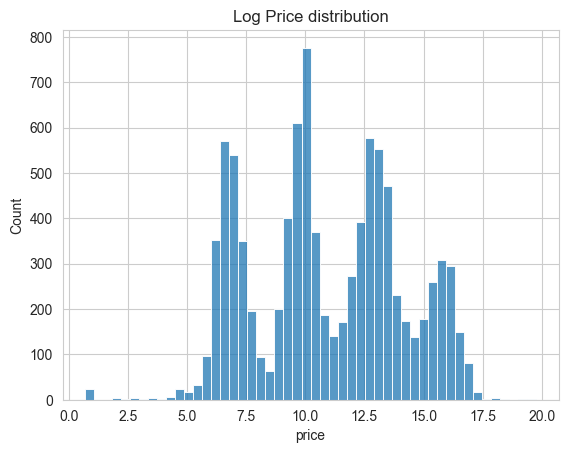

In [16]:
plt.figure()
sns.histplot(np.log1p(df["price"]), bins=50)
plt.title("Log Price distribution")
plt.show()


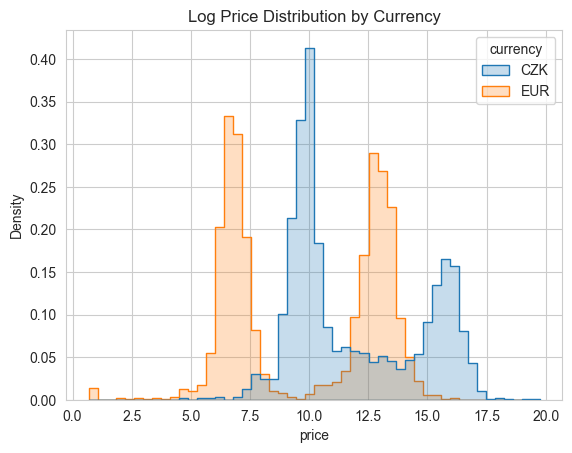

In [17]:
plt.figure()
sns.histplot(
    data=df,
    x=np.log1p(df["price"]),
    hue="currency",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Log Price Distribution by Currency")
plt.show()


### We can see two peaks for each currency. 
This stems from having two different economic regimes - rent vs sale

In [18]:
df["transaction_type"] = np.where(
    df["url"].str.contains("pronajem"),
    "rent",
    "sale"
)

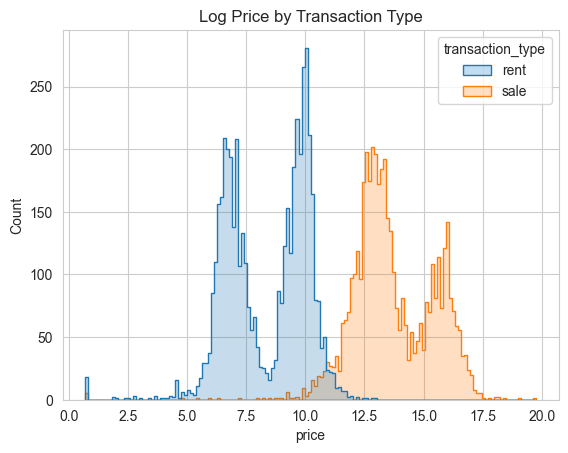

In [19]:
sns.histplot(
    data=df,
    x=np.log1p(df["price"]),
    hue="transaction_type",
    bins=150,
    element="step",
    common_norm=False
)
plt.title("Log Price by Transaction Type")
plt.show()


In [20]:
df.groupby(["currency", "transaction_type"])["price"].median() # Statistical proof

currency  transaction_type
CZK       rent                  18000.0
          sale                3692750.0
EUR       rent                    900.0
          sale                 410000.0
Name: price, dtype: float64

# Correlation matrix

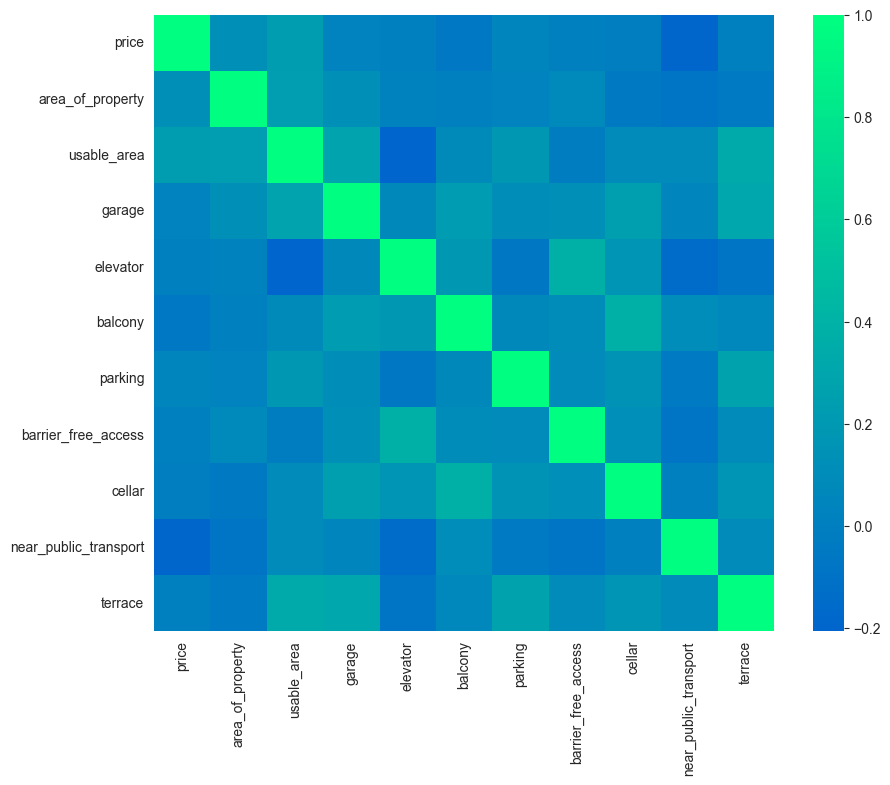

In [21]:
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="winter", center=0)
plt.show()


- The **barrier-free access** feature shows a strong positive correlation with the **elevator** feature.  
- Interestingly, **having an elevator** is negatively correlated with **usable area**, likely because elevators are typically found in flats within buildings rather than in larger houses.  
- **Price** increases with **usable area** and **area of property**, as expected.  
- **Terrace** and **garage** features are strongly correlated with **usable area**, suggesting larger properties are more likely to have these amenities.

price                    1.000000
elevator                 0.217557
area_of_property         0.208100
usable_area              0.092475
garage                   0.016747
barrier_free_access     -0.018218
terrace                 -0.020050
parking                 -0.035811
balcony                 -0.112082
cellar                  -0.175466
near_public_transport   -0.202255
Name: price, dtype: float64


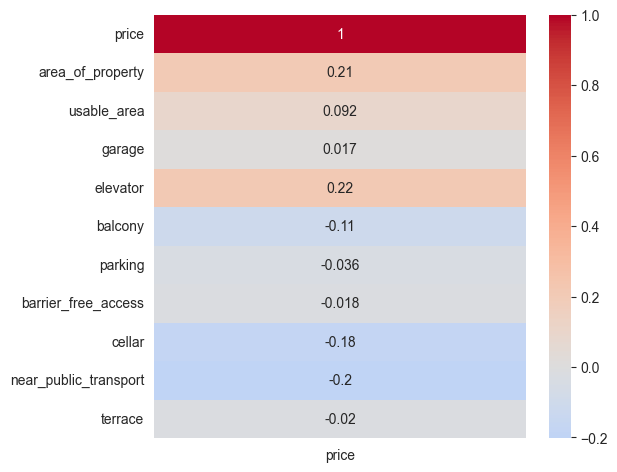

In [22]:
# Filter rows
df_sale = df[df['transaction_type'] == 'rent']

# Select numeric columns
num_cols = df_sale.select_dtypes(include=np.number).columns

# Compute correlation with price
corr_with_price = df_sale[num_cols].corr()['price'].sort_values(ascending=False)
print(corr_with_price)

plt.figure(figsize=(6, len(num_cols)*0.5))
sns.heatmap(df_sale[num_cols].corr()[['price']], annot=True, cmap="coolwarm", center=0)
plt.show()


price                    1.000000
area_of_property         0.101750
usable_area              0.092654
elevator                 0.082414
parking                  0.065494
barrier_free_access      0.027963
garage                  -0.016853
terrace                 -0.037927
cellar                  -0.045225
balcony                 -0.085915
near_public_transport   -0.288991
Name: price, dtype: float64


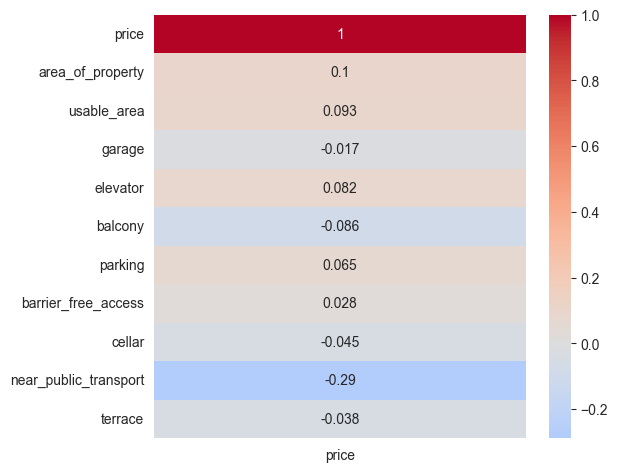

In [23]:
# Filter rows
df_sale = df[df['transaction_type'] == 'sale']

# Select numeric columns
num_cols = df_sale.select_dtypes(include=np.number).columns

# Compute correlation with price
corr_with_price = df_sale[num_cols].corr()['price'].sort_values(ascending=False)
print(corr_with_price)

plt.figure(figsize=(6, len(num_cols)*0.5))
sns.heatmap(df_sale[num_cols].corr()[['price']], annot=True, cmap="coolwarm", center=0)
plt.show()
